# ============================================
# INTELLIGENT DIABETES RISK PREDICTOR
# Student: Hanzala Iftikhar
# Course: CS619 - Final Year Project
# ============================================


In [ ]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
# loading dataset
df = pd.read_csv('/content/pima-indians-diabetes.data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,preg,plas,pres,Skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(df.columns.tolist())

['preg', ' plas', 'pres', 'Skin ', 'test', 'mass', 'pedi', 'age', 'class']


In [ ]:
# cleaning the column names
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['preg', 'plas', 'pres', 'Skin', 'test', 'mass', 'pedi', 'age', 'class']


EDA

In [ ]:
# doing EDA

# dataset shape
print(df.shape)
# Data Types & Null Values
print(df.info())


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   Skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
# basic statistical summary
df.describe()

,preg,plas,pres,Skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Zero Values Count
zero_cols = ['pres', 'plas', 'Skin', 'mass']
for i in zero_cols:
  zeros = (df[i] == 0).sum()
  print(f"{i}: {zeros} zeros")

pres: 35 zeros
plas: 5 zeros
Skin: 227 zeros
mass: 11 zeros


In [ ]:
print(f"test: {(df['test']==0).sum()} zeros")

test: 374 zeros


In [ ]:
# fixing the zero values

# droping Skin and test  - too many zeros
df = df.drop(columns=['Skin', 'test'])

# pres, plas and mass values filling them with median
df['pres'] = df['pres'].replace(0, df['pres'].median())
df['plas'] = df['plas'].replace(0, df['plas'].median())
df['mass'] = df['mass'].replace(0, df['mass'].median())

print("Zaero values fixed!")
df.shape


Zaero values fixed!


(768, 7)

Making EDA Graphs

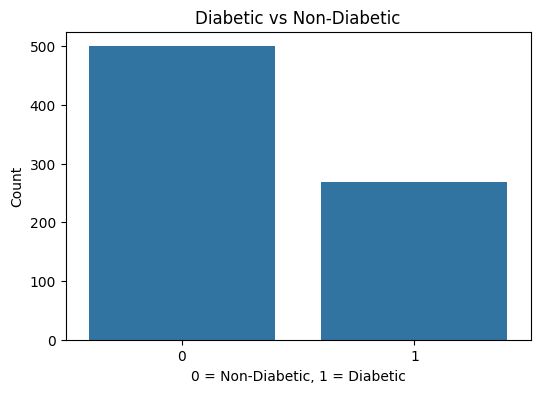

In [ ]:
# 3.4 Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Diabetic vs Non-Diabetic')
plt.xlabel('0 = Non-Diabetic, 1 = Diabetic')
plt.ylabel('Count')
plt.show()



In [ ]:
# as we can see the dataset is inbalanced
# Non-Diabetic (0): 500 — 65%
# Diabetic (1): 268 — 35%

# it is acceptable but we are still going to improve it a little.
print((df['class']).value_counts())

class
0    500
1    268
Name: count, dtype: int64


Balancing the Dataset

In [ ]:
# splitting the dataset
X = df.drop(columns=['class'])
Y = df['class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)



In [ ]:
!pip install imbalanced-learn

In [ ]:
# Fixing Imbalanced Dataset using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, Y_train = smote.fit_resample(X_train, Y_train)

print("X_train shape after SMOTE:", X_train.shape)
print("Y_train distribution:", Y_train.value_counts().to_dict())
print("X_test shape:", X_test.shape)

X_train shape after SMOTE: (698, 6)
Y_train distribution: {0: 349, 1: 349}
X_test shape: (231, 6)


Correlation heatmap

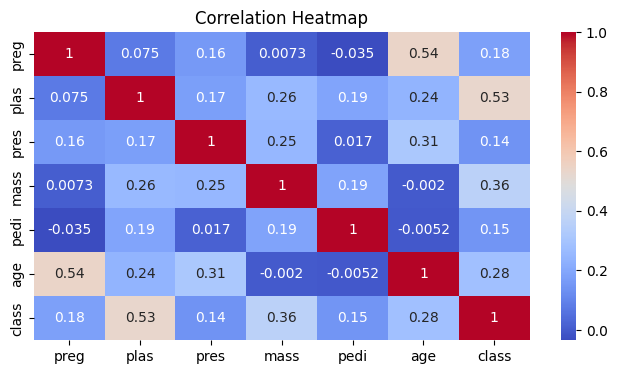

In [ ]:
# correlation
plt.figure(figsize=(8,4))
corr_df = pd.DataFrame(X_train, columns= X.columns)
corr_df['class'] = Y_train.values
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Feature Scaling done!')

Feature Scaling done!


## Model Training and Evaluation

In [ ]:
# LOGISTIC REGRESSION MODEL

LR_model = LogisticRegression(random_state=42)
LR_model = LR_model.fit(X_train, Y_train)
LR_predict = LR_model.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(Y_test, LR_predict):.4f}")
print(f"Precision: {precision_score(Y_test, LR_predict):.4f}")
print(f"Recall:    {recall_score(Y_test, LR_predict):.4f}")
print(f"F1 Score:  {f1_score(Y_test, LR_predict):.4f}")

=== Logistic Regression ===
Accuracy:  0.7013
Precision: 0.5591
Recall:    0.6500
F1 Score:  0.6012


In [ ]:
# DECISION TREE MODEL

DT_model = DecisionTreeClassifier(random_state=42)
DT_model = DT_model.fit(X_train, Y_train)
DT_predict = DT_model.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy:  {accuracy_score(Y_test, DT_predict):.4f}")
print(f"Precidion: {precision_score(Y_test, DT_predict):.4F}")
print(f"Recall:    {recall_score(Y_test, DT_predict):.4F}")
print(f"F1 Score:  {f1_score(Y_test, DT_predict):.4F}")

=== Decision Tree ===
Accuracy:  0.6970
Precidion: 0.5490
Recall:    0.7000
F1 Score:  0.6154


In [ ]:
# SVM -- Support Vector Machine

SVM_model = SVC(random_state=42)
SVM_model = SVM_model.fit(X_train, Y_train)
SVM_predict = SVM_model.predict(X_test)

print("=== Support Vector Machine ===")
print(f"Accuracy:  {accuracy_score(Y_test, SVM_predict):.4f}")
print(f"Precision: {precision_score(Y_test, SVM_predict):.4f}")
print(f"Recall:    {recall_score(Y_test, SVM_predict):.4f}")
print(f"F1 Score:  {f1_score(Y_test, SVM_predict):.4f}")

=== Support Vector Machine ===
Accuracy:  0.7143
Precision: 0.5648
Recall:    0.7625
F1 Score:  0.6489


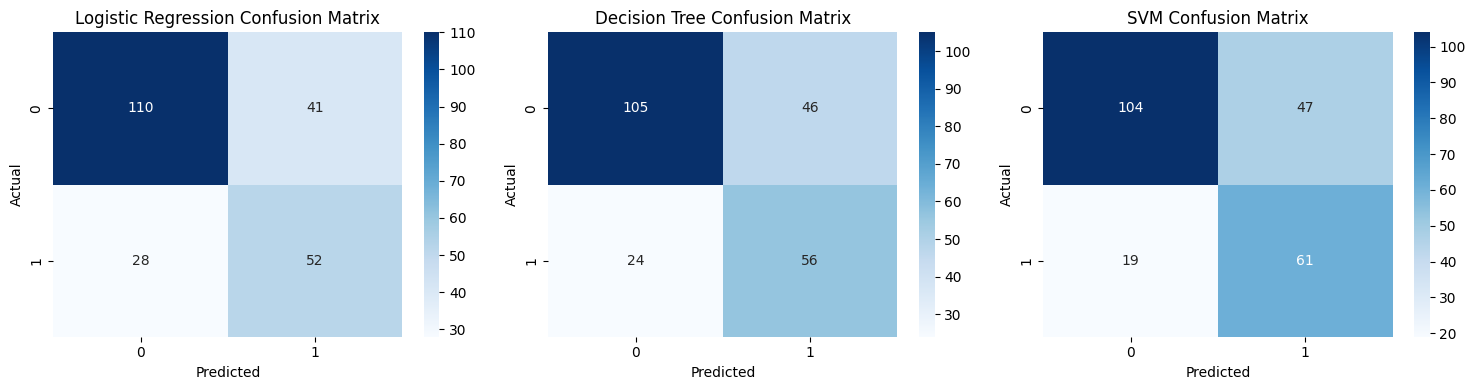

In [ ]:
# Confusion Matrix

fig, axes = plt.subplots(1,3, figsize=(15,4))

models = {
    'Logistic Regression': LR_predict,
    'Decision Tree': DT_predict,
    'SVM': SVM_predict
}

for ax, (name, pred) in zip(axes, models.items()):
  cm = confusion_matrix(Y_test, pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
  ax.set_title(f'{name} Confusion Matrix')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Final Model Comparison
print("=" * 55)
print(f"{'Model':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("=" * 55)
print(f"{'Logistic Regression':<25} {0.7013:>6.4f} {0.5591:>6.4f} {0.6500:>6.4f} {0.6012:>6.4f}")
print(f"{'Decision Tree':<25} {0.6970:>6.4f} {0.5490:>6.4f} {0.7000:>6.4f} {0.6154:>6.4f}")
print(f"{'SVM':<25} {0.7143:>6.4f} {0.5648:>6.4f} {0.7625:>6.4f} {0.6489:>6.4f}")
print("=" * 55)
print(f"\nBest Model: SVM (highest Recall & F1 Score)")

Model                        Acc   Prec    Rec     F1
Logistic Regression       0.7013 0.5591 0.6500 0.6012
Decision Tree             0.6970 0.5490 0.7000 0.6154
SVM                       0.7143 0.5648 0.7625 0.6489

Best Model: SVM (highest Recall & F1 Score)


## Saving The Model

In [ ]:
# Sving the SVM model
import joblib

joblib.dump(SVM_model, 'diabetes_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("SVM model saved!")
print("Scaler saved")

SVM model saved!
Scaler saved


In [ ]:
# downloading the files
from google.colab import files
files.download('diabetes_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Apne poore dataset pe chalao
all_scores = SVM_model.decision_function(X_test)

print("Minimum score:", all_scores.min())
print("Maximum score:", all_scores.max())
print("Average score:", all_scores.mean())

Minimum score: -2.2439637365980634
Maximum score: 2.448845894957948
Average score: -0.2102790389182488
